# 2BSDE Implementation

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
import numpy as np
from scipy.optimize import minimize

In [3]:
import matplotlib.pyplot as plt

In [4]:
# device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
# print(f"Using {device} device")

# 1. An $\mathbb{R}^d$-valued Example with an Explicit Solution

## 1.1. Formulation and Solution

Let us consider a SLQ problem as follows. 

$$
    \mathrm{d}X_t = (A \cdot X_t + B \cdot u_t) \mathrm{d}t + I \cdot \mathrm{d}W_t, \quad X_0 = x \in \mathbb{R}^{d}, 
$$

where $A$, $B$ are some $d \times d$ matrices, $I$ is $d \times d$ identity matrix, $W_t$ is a $d$-dimensional standard Brownian motion, and $u_t$ is the control process. 

Let the cost functional be 

$$
    J(u; x) = \mathbb{E} \left[ \int_0^T \left( X_t^\top Q X_t + u_t^\top R u_t \right) \mathrm{d}t + X_T^\top F X_T \right], 
$$

where $Q$, $R$ and $F$ are symmetric matrices. 

Define the value function as 

$$
    V(t, x) = \inf_{u} \mathbb{E} \left[ \int_t^T \left( X_t^\top Q X_t + u_t^\top R u_t \right) \mathrm{d}t + X_T^\top F X_T \right],\ x \in \mathbb{R}^d.
$$

By SLQ theory, the optimal control is given by 

$$
    u^*_t = - K(t)  \cdot X_t,
$$

where 

$$
    K(t) = R^{-1} B^{\top} P(t), 
$$

and the $d \times d$ matrix $P(t)$ is the solution to the Riccati equation

$$
    -\frac{\mathrm{d}P(t)}{\mathrm{d}t} = P(t) A + A^\top P(t) - P(t) B R^{-1} B^\top P(t) + Q, \quad P(T) = F.
$$

Let's consider the explicit case where, $d=10$, $A = B = R = F = I$, $Q = 3I$. In this case, we have a decoupled system, where 

$$
    P(t)= p(t) I, \ p(t) \in \mathbb{R}, \quad K(t) = P(t), 
$$
$$
    - \frac{\mathrm{d}p(t)}{\mathrm{d}t} = 2p(t) - p^2(t) + 3, \quad p(T) = 1.
$$
$$
    \implies \frac{\mathrm{d}p(t)}{\mathrm{d}t} = \left(p^2(t) - 3 \right) \left(p(t)+1\right), \quad p(T) = 1.
$$

Solve 

$$
    \int_t^T \left(\frac{1}{4}\frac{1}{p-3} - \frac{1}{4} \frac{1}{p-1}\right) \mathrm{d}p = T - t + C, \quad p(T) = 1, 
$$
$$
    \implies \ln(|p(T)-3|) - \ln(|p(T)+1|) - \ln(|p(t)-3|) + \ln(|p(t)+1|) = 4(T-t) + C, \quad p(T) = 1, 
$$
$$
    \implies \frac{p(t)+1}{3 - p(t)} = Ce^{4(T-t)}, \quad p(T)=1,
$$
$$
    \implies p(t) = \frac{3 C e^{4(T-t)} - 1}{1 + C e^{4(T-t)}}, \quad p(T) = 1, 
$$
$$
    \implies p(t) = \frac{3 e^{4(T-t)} - 1}{1 + e^{4(T-t)}}. 
$$


So the optimal control is

$$
    \textcolor{red}{u^*_t = - \frac{3 e^{4(T-t)} - 1}{1 + e^{4(T-t)}} X_t.}
$$

The HJB equation for the value function is given by

\begin{align*}
    \partial_t V(t, x) + \inf_{u} \left( 3 x^\top I x + u^\top I u + (x^{\top} I + u^{\top} I) \nabla_x V(t, x) + \frac{1}{2}\text{Tr}(\nabla_x^2 V(t, x)) \right) &= 0, \\
    V(T, x) &= x^{\top} I x.
\end{align*}

Now we follow the scheme of 2BSDE method to solve this HJB equation. Let's first rewrite the HJB as 

\begin{align*}
        \partial_t V(t, x) + b(x) \nabla_x V(t, x) + \frac{1}{2} \text{Tr}(\lambda \lambda^{\top}(x) \nabla_x^2 V(t, x)) &= F(t, x), \\
         V(T, x) &= g(x),
\end{align*}

where 

$$
    F(t, x) = b(x) \nabla_x V(t, x) + \frac{1}{2} \text{Tr}(\lambda \lambda^{\top}(x) \nabla_x^2 V(t, x)) - \inf_{u} \left( 3 x^\top I x + u^\top I u + (x^{\top} I + u^{\top} I) \nabla_x V(t, x) + \frac{1}{2}\text{Tr}(\nabla_x^2 V(t, x)) \right). 
$$

In this case, let's choose $b(x) = x^{\top} I  + \mathbf{1}$, and $\lambda(x) = I$, i.e. we have 

$$
    F(t, x) = \nabla_x V(t, x)^{\top} (x^{\top} I + \mathbf{1}) - \inf_u \tilde{F}(t, x, u), 
$$

where 

$$
    \tilde{F}(t, x, u) =  3 x^\top I x + u^\top I u + (x^{\top} I + u^{\top} I) \nabla_x V(t, x).
$$


Let the time horizon be $T=1$ and the number of time steps be $n=100$, i.e. $\Delta t = T/n = 0.01$. Then the E-M scheme is given by 

$$
    \mathcal{X}_{i+1} = \mathcal{X}_i + (\mathcal{X}_i^{\top} I + \mathbf{1}) \Delta t + \Delta W_i^{\top} I, \quad i = 0, 1, \ldots, n-1,\ \mathcal{X}_0 = x,\ \Delta W_i = W_{i+1} - W_i \sim \mathcal{N}(0, \Delta t I). 
$$

## 1.2. Implementation 

### 1.2.1. Model Construction

$$
    \tilde{F}(t, x, u) =  3 x^\top I x + u^\top I u + (x^{\top} I + u^{\top} I) \nabla_x V(t, x).
$$

In [5]:
# \tilde{F}(x) function 
def F_tilde(u, x, z):
    X = np.asarray(x, dtype=float)
    U = np.asarray(u, dtype=float)
    Z = np.asarray(z, dtype=float)
    dim = len(x)
    I = np.eye(dim, dtype=float)
    return  3.0 * np.dot(X, X) + np.dot(U, U) + np.dot(X+U, Z)

In [6]:
# test F_tilde function
F_tilde(torch.tensor([0], dtype=torch.float64), 
        torch.tensor([2], dtype=torch.float64), 
        torch.tensor([0], dtype=torch.float64))

12.0

In [7]:
# test minimize() on F_tilde
x = np.array([2])
z = np.array([0.0])
u0=np.array([5.0])
res = minimize(F_tilde, u0, args=(x, z))
print(res.x) # note that the output type is float
print(res.fun)
print(torch.tensor([res.x], dtype=torch.float64)) # need to transfer to torch.float64
print(torch.tensor([res.fun], dtype=torch.float64))

[-2.62955131e-08]
12.0
tensor([[-2.6296e-08]], dtype=torch.float64)
tensor([12.], dtype=torch.float64)


/var/folders/cg/257n3sdd2sn56fkv__mcxx3h0000gn/T/ipykernel_1455/1998011258.py:8: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1744233399171/work/torch/csrc/utils/tensor_new.cpp:257.)
  print(torch.tensor([res.x], dtype=torch.float64)) # need to transfer to torch.float64


The true drift function is 
$$
    \mu(u, x) = (x + u)I. 
$$

The auxiliary drift function is 
$$
    b(x) = x^{\top} I  + \mathbf{1}, 
$$
where we choose $u \equiv 1$.

In [8]:
# auxiliary b(x) function
def aux_drift_b(u, x):
    dim = x.shape[0]
    I = torch.eye(dim, dtype=torch.float64)
    return x @ I + u @ I

In [9]:
# auxiliary lambda(x) function 
# which will just be the identity matrix in this case
def aux_diff_lambda(x):
    dim = x.shape[0]
    I = torch.eye(dim, dtype=torch.float64)
    return I

Recall that the Neural-Network approximated 2BSDE is given by 

\begin{equation*}
        \begin{cases}
            \mathcal{Y}^{\theta, j}_{i+1} &= \mathcal{Y}^{\theta, j}_{i} + F\big( \mathcal{X}^j_{t_{i}}, \mathcal{Y}^{\theta, j}_{i}, \mathcal{Z}^{\theta, j}_{i}, \mathbb{G}^{\theta}_i(\mathcal{X}^j_{t_i}) \big) \Delta t + \mathcal{Z}^{\theta, j}_{i} \lambda(\mathcal{X}^j_{t_i}) (W^j_{t_{i+1}} - W^j_{t_{i}}), \\ 
            \mathcal{Y}^{\theta, j}_0 &= \mathbb{V}^{\theta}_0(\pmb{\mu}), \\
            \mathcal{Z}^{\theta, j}_{i+1} &= \mathcal{Z}^{\theta, j}_{i} + \mathbb{A}^{\theta}_{i}(\mathcal{X}^j_{t_i}) \Delta t + \mathbb{G}^{\theta}_{i}(\mathcal{X}^j_{t_i}) \lambda(\mathcal{X}^j_{t_i}) (W^j_{t_{i+1}} - W^j_{t_{i}}), \\
            \mathcal{Z}^{\theta}_0 &= \mathbb{Z}^{\theta}_0(\pmb{\mu}), 
        \end{cases}
    \end{equation*}

where $j = 1, \ldots, M$ means we will simulate $M$ number paths of $(\mathcal{X}_t)_{t=0}^T$. 

The $\mathbb{V}_0^{\theta}$, $\mathbb{Z}_0^{\theta}$, and $\mathbb{A}_{i}^{\theta}$, $\mathbb{G}_{i}^{\theta}$, $i=0, \ldots, n$ means they will be approximated by the neural network. 

The $\mathcal{X}_i$, $\mathcal{Y}_i^{\theta}$, $\mathcal{Z}_i^{\theta}$ means that they are numerical results based on the neural network approximation. They will be calculated due to the E-M scheme, but not directly approximated by the neural network.

In [10]:
# For the structure of tensor A^theta, check p.1572, Beck et. al., 2019
# or figure 1, p.1575 
class A_Net(nn.Module):
    def __init__(self, dim):
        if dim <= 64:
            d = 64
        else:
            d = dim
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features=dim, out_features=d, bias=True).double(),
            #nn.BatchNorm1d(d),
            nn.ReLU(),
            nn.Linear(in_features=d, out_features=d, bias=True).double(), 
            #nn.BatchNorm1d(d),
            nn.ReLU(),   
            nn.Linear(in_features=d, out_features=dim, bias=True).double(),
        )

    def forward(self, x):
        return self.net(x)

In [11]:
# test A_Net
model = A_Net(dim=10)
x = torch.rand(128, 10, dtype=torch.float64)  # batch_size=128, dim=10
y = model(x)
print(y.shape)
print(y[0])

torch.Size([128, 10])
tensor([-0.0406,  0.0425, -0.0626,  0.0505, -0.1540, -0.1320, -0.0245, -0.0689,
        -0.0891, -0.0096], dtype=torch.float64, grad_fn=<SelectBackward0>)


In [12]:
# For the structure of G, check p.1572, Beck et. al., 2019.
class G_Net(nn.Module):
    def __init__(self, dim):
        if dim <= 64:
            d = 64
        else:
            d = dim
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features=dim, out_features=d, bias=True).double(),
            #nn.BatchNorm1d(d),
            nn.ReLU(),
            nn.Linear(in_features=d, out_features=d, bias=True).double(), 
            #nn.BatchNorm1d(d),
            nn.ReLU(),   
            nn.Linear(in_features=d, out_features=dim*dim, bias=True).double(),
        )
        self.dim = dim

    def forward(self, x):
        batch_size = x.shape[0]
        out = self.net(x)
        # reshape the output to a batch_size*dim*dim tensor
        return out.view(batch_size, self.dim, self.dim) 

In [13]:
# test G_net
model = G_Net(dim=10)
x = torch.rand(128, 10, dtype=torch.float64)  # batch_size=128, dim=10
y = model(x)
print(y.shape)
print(y[0])

torch.Size([128, 10, 10])
tensor([[ 0.0876, -0.0264,  0.0541,  0.0336,  0.1050,  0.0758, -0.0246,  0.1314,
         -0.0065,  0.0044],
        [ 0.1480, -0.0382,  0.1093,  0.0696, -0.0937,  0.0932, -0.1349,  0.0217,
         -0.1108, -0.0457],
        [-0.1613, -0.1354,  0.0404,  0.1636,  0.1196,  0.0510, -0.0916,  0.0352,
         -0.1623, -0.0356],
        [-0.0515,  0.1412, -0.0989, -0.0621,  0.0203,  0.0033,  0.0235,  0.1104,
         -0.0396, -0.1252],
        [ 0.0856, -0.0439,  0.0875,  0.0506,  0.0225, -0.0631,  0.0616, -0.1413,
          0.0948, -0.0855],
        [ 0.1340,  0.0781, -0.0617,  0.0182, -0.0231,  0.0503, -0.0365,  0.0872,
          0.0227, -0.0188],
        [-0.1189, -0.0370,  0.1089, -0.0456,  0.0727, -0.1607,  0.0906, -0.0946,
         -0.0851,  0.0697],
        [-0.1299, -0.0553, -0.0786,  0.1966,  0.0079, -0.0823,  0.1460, -0.1016,
          0.0577, -0.0018],
        [-0.0032, -0.1162, -0.0097,  0.0835, -0.1252,  0.0810,  0.0471,  0.0656,
         -0.1679, -0.

In [14]:
class ParallelBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.netA = A_Net(dim)
        self.netG = G_Net(dim)

    def forward(self, x):
        A_out = self.netA(x)
        G_out = self.netG(x)
        return A_out, G_out 

$$
    \mathcal{Y}^{\theta, j}_{i+1} = \mathcal{Y}^{\theta, j}_{i} + F\big( \mathcal{X}^j_{t_{i}}, \mathcal{Y}^{\theta, j}_{i}, \mathcal{Z}^{\theta, j}_{i}, \mathbb{G}^{\theta}_i(\mathcal{X}^j_{t_i}) \big) \Delta t + \mathcal{Z}^{\theta, j}_{i} \lambda(\mathcal{X}^j_{t_i}) (W^j_{t_{i+1}} - W^j_{t_{i}})
$$

$$
    \mathcal{Z}^{\theta, j}_{i+1} = \mathcal{Z}^{\theta, j}_{i} + \mathbb{A}^{\theta}_{i}(\mathcal{X}^j_{t_i}) \Delta t + \mathbb{G}^{\theta}_{i}(\mathcal{X}^j_{t_i}) \lambda(\mathcal{X}^j_{t_i}) (W^j_{t_{i+1}} - W^j_{t_{i}}) 
$$

$$
    F(t, x) = \nabla_x V(t, x)^{\top} (x^{\top} I + \mathbf{1}) - \inf_u \tilde{F}(t, x, u), 
$$

In [15]:
# Stack (step_num-1) layers of parallel net of A and G
# to form the deep network. 
# The first layer is parametrised by V0, Z0, A0, G0
# Also, between each layer, we have a specific structure of Y, Z, A, G

class DeepModel(nn.Module):
    def __init__(self, step_num:int, dim:int, x0:torch.FloatTensor, T:float, aux_u:torch.FloatTensor):
        '''
            Args: 
                step_num (integer): number of time discretisation steps. 
                dim (integer): dimension of X process
                x (torch.float64): initial value of X process, shape [dim]
                T (float): time horizon 
                aux_u (tensor, torch.float64): auxiliary control, shape [step_num, dim]
        '''
        super().__init__()
        if dim != x0.shape[0]:
            raise ValueError("Initial value x0 has wrong dimension. Should be consistent with dim argument.")
        if x0.dtype != torch.float64: 
            raise TypeError("Initial value x0 has wrong type. Expected torch.float64.")

        # we need step_num-1 number of parallel blocks
        # the first block will be parametrised by a list of parameters
        self.blocks = nn.ModuleList([ParallelBlock(dim) for _ in range(step_num-1)])
        
        # parameters for V_0, Z_0, A_0 and G_0, the initial block
        self.V0 = nn.Parameter(torch.randn(1, dtype=torch.float64))
        self.Z0 = nn.Parameter(torch.randn(dim, dtype=torch.float64))
        self.A0 = nn.Parameter(torch.randn(dim, dtype=torch.float64))
        self.G0 = nn.Parameter(torch.randn(dim, dim, dtype=torch.float64))
        
        self.step_num = step_num
        self.dim = dim
        self.x0 = x0
        self.T = T
        self.u = aux_u
        
    def forward(self, W: torch.FloatTensor): 
        '''
        Args:
            W(tensor, torch.float64): the brownian increments data, shape [batch_size, step_num, dim]
        
        Out: tuple(YT, u_opt)
            YT(tensor, torch.float64): terminal value of Y 
            u_opt(tensor, torch.float64): optimal control process
        '''
        batch_size, step_num, dim = W.shape 
        # The step number should match the number of parallel blocks. 
        if step_num != self.step_num: 
            raise ValueError("The step_num dimension of the data is wrong.")

        # Same for dimension in this case. 
        # NB: but not in general, as we can enlarge or shrink the width of A net or G net. Check the code for A net and G net. 
        if dim != self.dim: 
            raise ValueError("The dim dimension of the data is wrong.")

        I = torch.eye(dim, dtype = torch.float64)
        one_vector = torch.ones(dim, dtype = torch.float64)        
        dt = self.T / self.step_num
        u = []
        u0 = np.ones(dim) # initial guess for minimize() function
        YT = None

        u_opt = []
        x_prev = []
        y_prev = []
        z_prev = []

        # for the initial block
        x = np.array(self.x0)
        z = self.Z0.detach().numpy()
        res = minimize(F_tilde, u0, args=(x, z))
        ub_opt = torch.tensor(res.x, dtype=torch.float64) # this is u^{b,*}_0
        F_tilde_value = torch.tensor([res.fun], dtype=torch.float64) # shape [1]
        F_value = (self.x0 @ I + one_vector) @ self.Z0 - F_tilde_value
        for b in range(batch_size):
            u_opt.append(ub_opt) # this is u^*_i
            xb_new = self.x0 + aux_drift_b(self.u[0], self.x0) * dt + aux_diff_lambda(self.x0) @ W[b][0] # xb_new is X^b_{1}
            yb_new = self.V0 + F_value * dt + self.Z0 @ I @ W[b][0] # yb_new is Y^b_{1}
            zb_new = self.Z0 + self.A0 * dt + self.G0 @ I @ W[b][0] # zb_new is Z^b_{1}
            
            x_prev.append(xb_new)
            y_prev.append(yb_new)
            z_prev.append(zb_new)

        u_opt = torch.stack(u_opt)
        u.append(u_opt)
        x_prev = torch.stack(x_prev)
        y_prev = torch.stack(y_prev)
        z_prev = torch.stack(z_prev)

        # i = 0,...,(step_num-2), but will represent the (i+1)th block
        # i.e. (i=0 is block1), (i=1 is block2), ..., (i=N-2 is block(N-1)), index shifted
        for i, block in enumerate(self.blocks): 
            x_new = []
            y_new = []
            z_new = []
            u_opt = []
            netA, netG = block(x_prev)
            for b in range(batch_size):    
                x = np.array(x_prev[b])
                z = z_prev[b].detach().numpy()
                res = minimize(F_tilde, u0, args=(x, z))
                ub_opt = torch.tensor(res.x, dtype=torch.float64) # this is u^{b,*}_{i+1}, 
                F_tilde_value = torch.tensor([res.fun], dtype=torch.float64) # shape [1]
                F_value = (x_prev[b] @ I + one_vector) @ z_prev[b] - F_tilde_value
                
                xb_new = x_prev[b] + aux_drift_b(self.u[i+1], x_prev[b]) * dt + aux_diff_lambda(x_prev[b]) @ W[b][i+1] # xb_new is X^b_{i+2}
                yb_new = y_prev[b] + F_value * dt + z_prev[b] @ aux_diff_lambda(x_prev[b]) @ W[b][i+1] # yb_new is Y^b_{i+2}
                zb_new = z_prev[b] + netA[b] * dt + netG[b] @ aux_diff_lambda(x_prev[b]) @ W[b][i+1] # zb_new is Z^b_{i+2}

                u_opt.append(ub_opt)
                x_new.append(xb_new)
                y_new.append(yb_new)
                z_new.append(zb_new)

            YT = y_new 
            u_opt = torch.stack(u_opt)
            u.append(u_opt)
            x_prev = torch.stack(x_new)
            y_prev = torch.stack(y_new)
            z_prev = torch.stack(z_new)

        return torch.stack(YT, dim=0).squeeze(1), torch.stack(u).permute(1,0,2)

### 1.2.2. Model Test

In [16]:
T_TEST = 1.0
STEP_NUM_TEST = 10
DIM_TEST = 2
BATCH_SIZE_TEST = 20
x0_TEST = torch.zeros(DIM_TEST, dtype=torch.float64)
AUX_U0_TEST = torch.ones(STEP_NUM_TEST, DIM_TEST, dtype=torch.float64)

In [17]:
def W_sim(step_num:int, T:float, dim:int):
    ''' 
    This function simulate single standard Brownian increments. 
        Args:
            step_num(integer): the number of time discretisation steps
            T(float): time horizon
            dim(integer): the dimension of the Brownian motion
        Outputs:
            W(tensor, torch64loat32): single Brownian increments sample, shape [step_num, dim]
    '''
    W = []
    dt = T / step_num
    for i in range(step_num):
        w = (dt**0.5)*torch.randn(dim, dtype=torch.float64)
        W.append(w) 
    W = torch.stack(W)
    return W

In [18]:
# test W_sim()

W_test = W_sim(step_num = STEP_NUM_TEST, T=T_TEST, dim=DIM_TEST)
print(W_test) 

tensor([[ 0.0178, -0.1582],
        [-0.2084,  0.0385],
        [ 0.4926, -0.1234],
        [-0.2483,  0.0056],
        [-0.6942,  0.3075],
        [ 0.0983,  0.1512],
        [-0.0083, -0.3714],
        [-0.8828, -0.0211],
        [-0.2559,  0.2785],
        [ 0.5891, -0.2835]], dtype=torch.float64)


In [19]:

def generate_W_data(batch_size:int, step_num:int, T:float, dim:int):
    '''
    To generate W data (Brownian increments) in batches.
        Args: 
            batch_size(integer): the number of samples one wants to generate
            step_num(integer): the time discretisation step numbers
            T(float): time horizon 
            dim(integer): the dimension of the data
        Outputs:
            W(tensor, torch.float64): shape [batch_size, step_num, dim]
    '''
    W = []
    for b in range(batch_size):
        w = W_sim(step_num, T, dim)
        W.append(w)
    W = torch.stack(W, dim=0)  # shape [batch_size, step_num, dim]
    return W

In [20]:
# test generate_W_data()

W_data_test = generate_W_data(batch_size=BATCH_SIZE_TEST, step_num=STEP_NUM_TEST, T=T_TEST, dim=DIM_TEST)
print(W_data_test.shape)
print(W_data_test)

torch.Size([20, 10, 2])
tensor([[[ 1.9522e-01,  1.1855e-01],
         [-2.2872e-01,  5.5416e-01],
         [ 4.0539e-01,  1.9208e-01],
         [ 4.9566e-01, -2.3986e-01],
         [-1.9646e-01, -2.2009e-01],
         [-1.9693e-01, -6.7859e-01],
         [ 1.2660e-01,  2.3400e-01],
         [ 3.6300e-01,  2.5833e-01],
         [ 5.1116e-01, -3.1759e-01],
         [-5.5131e-01, -7.4429e-02]],

        [[ 5.7670e-02, -3.2601e-01],
         [ 1.1593e-01,  4.8323e-02],
         [-9.4974e-02, -1.0952e-01],
         [-4.8064e-01,  2.0110e-01],
         [-3.5234e-01, -3.9041e-01],
         [ 1.3523e-01,  1.1736e-01],
         [ 5.2961e-01, -2.4639e-01],
         [-2.0792e-01,  4.5344e-01],
         [ 4.0786e-01, -5.4655e-02],
         [ 1.7290e-01,  2.1697e-01]],

        [[ 2.9823e-01, -3.4183e-01],
         [-2.6140e-02,  2.1092e-01],
         [-2.8777e-01,  1.3353e-01],
         [ 4.4871e-01, -2.0157e-01],
         [ 3.6841e-01,  4.4113e-02],
         [ 5.1016e-01, -4.6332e-01],
         [

In [21]:
def X_data_from_W_data(x_init:torch.FloatTensor, T:float, W_data:torch.FloatTensor, aux_u:torch.FloatTensor): 
    ''' 
        Construct X data from a given W data through Euler-Maruyama scheme.
            Args: 
                x_init (tensor, torch.float64): initial value of X
                T (float): time horizon
                W_data (tensor, torch.float64): the given W data
                aux_u (tensor, torch.float64): auxiliary control, shape [step_num, dim]
            Outputs:
                X (tensor, torch.float64): the constructed X data, same shape of W data
    '''
    batch_size, step_num, dim = W_data.shape
    if x_init.shape[0] != dim:
        raise ValueError("The dimension of the initial value of X is wrong. Should match dim of W.")
    dt = T / step_num
    X = []
    for b in range(batch_size):
        x = x_init.clone().detach().to(dtype=torch.float64)
        Xb = []
        Wb = W_data[b]
        for i in range(step_num): 
            x = x + aux_drift_b(aux_u[i], x) * dt + aux_diff_lambda(x) @ Wb[i]
            Xb.append(x)
        Xb = torch.stack(Xb)
        X.append(Xb)
    X = torch.stack(X)
    return X

In [22]:
# test X_data_from_W_data()
X_data_test = X_data_from_W_data(x_init=x0_TEST, T=T_TEST, W_data=W_data_test, aux_u = AUX_U0_TEST)
print(X_data_test.shape)
print(X_data_test)

torch.Size([20, 10, 2])
tensor([[[ 2.9522e-01,  2.1855e-01],
         [ 1.9601e-01,  8.9456e-01],
         [ 7.2100e-01,  1.2761e+00],
         [ 1.3888e+00,  1.2638e+00],
         [ 1.4312e+00,  1.2701e+00],
         [ 1.4774e+00,  8.1857e-01],
         [ 1.8517e+00,  1.2344e+00],
         [ 2.4999e+00,  1.7162e+00],
         [ 3.3610e+00,  1.6702e+00],
         [ 3.2458e+00,  1.8628e+00]],

        [[ 1.5767e-01, -2.2601e-01],
         [ 3.8936e-01, -1.0028e-01],
         [ 4.3333e-01, -1.1983e-01],
         [ 9.6019e-02,  1.6929e-01],
         [-1.4672e-01, -1.0419e-01],
         [ 7.3838e-02,  1.0275e-01],
         [ 7.1083e-01, -3.3360e-02],
         [ 6.7399e-01,  5.1674e-01],
         [ 1.2492e+00,  6.1376e-01],
         [ 1.6471e+00,  9.9211e-01]],

        [[ 3.9823e-01, -2.4183e-01],
         [ 5.1191e-01,  4.4906e-02],
         [ 3.7533e-01,  2.8292e-01],
         [ 9.6157e-01,  2.0965e-01],
         [ 1.5261e+00,  3.7472e-01],
         [ 2.2889e+00,  4.8872e-02],
         [

In [23]:
def get_XT(X_data:torch.FloatTensor):
    ''' 
    Get the final X_T value from X data
        Args: 
            X_data(tensor, torch.float64): the given X data
        Outputs:
            XT(tensor, torch.float64): the value of X_T in the data, shape [batch_size, dim]
    '''
    XT = [] 
    batch_size = X_data.shape[0]
    for b in range(batch_size):
        xT = X_data[b][-1]
        XT.append(xT)
    XT = torch.stack(XT)
    return XT

In [24]:
# test get_XT() 

XT_test = get_XT(X_data_test)
print(XT_test.shape)
print(XT_test)

torch.Size([20, 2])
tensor([[ 3.2458,  1.8628],
        [ 1.6471,  0.9921],
        [ 4.1338,  0.9689],
        [ 3.1295,  0.3628],
        [ 0.4819,  2.6455],
        [ 3.8420,  2.9403],
        [-1.0595,  0.3521],
        [ 1.5651,  0.9736],
        [-0.7591,  4.1425],
        [ 0.9406,  3.2983],
        [ 2.0540,  0.7383],
        [ 2.3854,  1.8257],
        [ 2.4691,  3.2633],
        [ 1.3044,  0.5725],
        [ 3.2730,  0.4655],
        [ 0.3355,  0.1275],
        [-0.5099,  0.5911],
        [-1.1312, -0.3103],
        [ 0.0426,  1.5888],
        [ 0.8228, -0.7061]], dtype=torch.float64)


In [25]:
def terminal_cost(XT:torch.FloatTensor):
    ''' 
    The terminal cost functional.
        Args: 
            XT(tensor, torch.float64): the terminal value X_T, shape [batch_size, dim]
        Outputs:
            G(tensor, torch.float64): the terminal cost, shape [batch_size]
    '''
    batch_size, dim = XT.shape
    G = []
    I = torch.eye(dim, dtype=torch.float64)
    for b in range(batch_size): 
        g = XT[b] @ I @ XT[b]
        G.append(g)
    G = torch.stack(G)
    return G


In [26]:
# test terminal_cost()

YT_test = terminal_cost(XT_test)
print(YT_test.shape)
print(YT_test)

torch.Size([20])
tensor([14.0054,  3.6971, 18.0273,  9.9254,  7.2308, 23.4064,  1.2466,  3.3977,
        17.7368, 11.7634,  4.7642,  9.0233, 16.7457,  2.0291, 10.9294,  0.1288,
         0.6093,  1.3758,  2.5260,  1.1755], dtype=torch.float64)


In [27]:
# test model 

torch.manual_seed(42)
model_test = DeepModel(step_num=STEP_NUM_TEST, dim=DIM_TEST, x0=x0_TEST, T=T_TEST, aux_u=AUX_U0_TEST)
model_test.eval()
y_pred_test, u_pred_test = model_test(W_data_test)
print(y_pred_test.shape)
print(u_pred_test.shape)
print(u_pred_test[0])

torch.Size([20])
torch.Size([20, 10, 2])
tensor([[ 0.7117, -0.0157],
        [ 0.7051,  0.0831],
        [ 0.7196,  0.1143],
        [ 0.7543,  0.0953],
        [ 0.7714,  0.0483],
        [ 0.7529,  0.0341],
        [ 0.8359,  0.1240],
        [ 0.8649,  0.1337],
        [ 0.8604,  0.1874],
        [ 0.7995,  0.2059]], dtype=torch.float64)


$$
    \textcolor{red}{u^*_t = - \frac{3 e^{4(T-t)} - 1 }{1 + e^{4(T-t)}} X_t.}
$$

In [28]:
def u_true_optimiser(X_data:torch.FloatTensor, T:float):
    batch_size, step_num, dim = X_data.shape
    output = []
    for b in range(batch_size): 
        ub = []
        for i in range(step_num): 
            ub_i = - (3 * np.exp(4*(T - i*T/step_num)) - 1) / (1 + np.exp(4*(T - i*T/step_num))) * X_data[b][i]
            ub.append(ub_i)
        ub = torch.stack(ub)
        output.append(ub)
    output = torch.stack(output)    
    return output

In [29]:
# test u_true_optimiser function
u_true_test = u_true_optimiser(X_data_test, T=T_TEST)
print(u_true_test.shape)
print(u_true_test)

torch.Size([20, 10, 2])
tensor([[[-8.6441e-01, -6.3991e-01],
         [-5.6719e-01, -2.5885e+00],
         [-2.0501e+00, -3.6284e+00],
         [-3.8479e+00, -3.5017e+00],
         [-3.8174e+00, -3.3879e+00],
         [-3.7277e+00, -2.0654e+00],
         [-4.3109e+00, -2.8738e+00],
         [-5.1850e+00, -3.5596e+00],
         [-5.9151e+00, -2.9394e+00],
         [-4.5271e+00, -2.5982e+00]],

        [[-4.6167e-01,  6.6176e-01],
         [-1.1267e+00,  2.9018e-01],
         [-1.2321e+00,  3.4072e-01],
         [-2.6604e-01, -4.6906e-01],
         [ 3.9135e-01,  2.7790e-01],
         [-1.8631e-01, -2.5926e-01],
         [-1.6549e+00,  7.7665e-02],
         [-1.3979e+00, -1.0718e+00],
         [-2.1985e+00, -1.0802e+00],
         [-2.2973e+00, -1.3837e+00]],

        [[-1.1660e+00,  7.0809e-01],
         [-1.4813e+00, -1.2994e-01],
         [-1.0672e+00, -8.0445e-01],
         [-2.6642e+00, -5.8087e-01],
         [-4.0707e+00, -9.9950e-01],
         [-5.7754e+00, -1.2331e-01],
         [

### 1.2.3. Model Training

In [30]:
# from torch.utils.data import DataLoader, TensorDataset
# dataset = TensorDataset(X_data, YT_true)
# loader = DataLoader(dataset, batch_size = 1, shuffle=True)

#### Model 1

In [31]:
T = 0.3
STEP_NUM = 20
DIM = 1
DT = T/STEP_NUM
X_INIT = torch.zeros(DIM, dtype=torch.float64)
AUX_U0 = torch.ones(STEP_NUM, DIM, dtype=torch.float64)

BATCH_SIZE = 64
EPOCHS = 500

model1 = DeepModel(step_num=STEP_NUM, dim=DIM, x0=X_INIT, T=T, aux_u=AUX_U0)
optimizer = optim.Adam(model1.parameters(), lr=0.01) # Adam optimizer
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.5)

loss_fn = nn.MSELoss() # mean square loos
losses = []

model1.train()
for epoch in range(1, EPOCHS+1):
    W = generate_W_data(BATCH_SIZE, STEP_NUM, T, DIM)
    X = X_data_from_W_data(X_INIT, T, W, AUX_U0)
    XT = get_XT(X)
    YT = terminal_cost(XT)
    y_pred, u_pred = model1(W)
    loss = loss_fn(y_pred, YT)
    losses.append(loss.item())
    '''
    batch_size, step_num, dim = u_pred.shape
    u_loss = 0.0
    for b in range(batch_size):
        ub_loss = 0.0 
        for i in range(step_num):
            ub_loss += torch.sum((u_true[b][i] - u_pred[b][i])**2)
        u_loss += ub_loss
    '''
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # if epoch % 100 == 0:
    #     old_state = model.state_dict()
    #     AUX_U0 = u_pred.mean(0)
    #     new_model = DeepModel(step_num=STEP_NUM, dim=DIM, x0=X_INIT, T=T, aux_u=AUX_U0)
    #     new_model.load_state_dict(old_state)
    #     model = new_model

    if epoch % 100 == 0: 
        scheduler.step()
        
    print(f"Epoch {epoch}, Loss: {loss.item():.4f}, lr: {scheduler.get_last_lr()[0]:.6}")

Epoch 1, Loss: 2.8501, lr: 0.01
Epoch 2, Loss: 0.7658, lr: 0.01
Epoch 3, Loss: 1.0533, lr: 0.01
Epoch 4, Loss: 1.5148, lr: 0.01
Epoch 5, Loss: 0.8869, lr: 0.01
Epoch 6, Loss: 0.7417, lr: 0.01
Epoch 7, Loss: 0.8036, lr: 0.01
Epoch 8, Loss: 0.7021, lr: 0.01
Epoch 9, Loss: 0.4454, lr: 0.01
Epoch 10, Loss: 0.4180, lr: 0.01
Epoch 11, Loss: 0.2990, lr: 0.01
Epoch 12, Loss: 0.3917, lr: 0.01
Epoch 13, Loss: 0.4987, lr: 0.01
Epoch 14, Loss: 0.3883, lr: 0.01
Epoch 15, Loss: 0.5887, lr: 0.01
Epoch 16, Loss: 0.5479, lr: 0.01
Epoch 17, Loss: 1.8081, lr: 0.01
Epoch 18, Loss: 0.3956, lr: 0.01
Epoch 19, Loss: 0.5073, lr: 0.01
Epoch 20, Loss: 0.2091, lr: 0.01
Epoch 21, Loss: 0.1778, lr: 0.01
Epoch 22, Loss: 0.1794, lr: 0.01
Epoch 23, Loss: 0.2264, lr: 0.01
Epoch 24, Loss: 0.1753, lr: 0.01
Epoch 25, Loss: 0.2164, lr: 0.01
Epoch 26, Loss: 0.2588, lr: 0.01
Epoch 27, Loss: 0.2721, lr: 0.01
Epoch 28, Loss: 0.2793, lr: 0.01
Epoch 29, Loss: 0.3278, lr: 0.01
Epoch 30, Loss: 0.1987, lr: 0.01
Epoch 31, Loss: 0.1

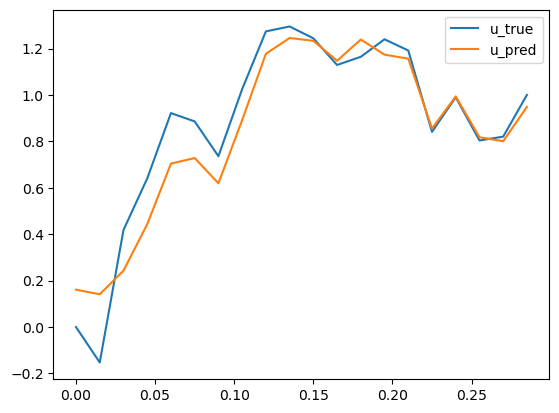

In [32]:
# re-run this cell to see different realisations and approximation results

W_single_sample = generate_W_data(batch_size=1, step_num=STEP_NUM, T=T, dim=DIM)
X_single_sample = X_data_from_W_data(x_init=X_INIT, T=T, W_data=W_single_sample, aux_u=AUX_U0) # this is [X_1, X_2, ..., X_T], shape [1, STEP_NUM, DIM]
u_true_single_sample = u_true_optimiser(X_single_sample, T=T) # this is [u^*_1, u^*_2, ..., u^*_T]

X_init_single_sample = X_INIT.unsqueeze(0).unsqueeze(1) # shape [1, 1, DIM] 
u0_true_single_sample = u_true_optimiser(X_init_single_sample, T=T)

u_true_single_sample = torch.cat((u0_true_single_sample, u_true_single_sample), dim=1) # this now includes u^*_0
X_single_sample = torch.cat((X_INIT.unsqueeze(0).unsqueeze(1), X_single_sample), dim=1) # this now includes X_0


model1.eval()
with torch.no_grad():
    # note that this predicted u is from time 0 up to T-dt, 
    # i.e. [u^{theta,*}_0, u^{theta,*}_1, ..., u^{theta,*}_{T-dt}]
    y_single_pred, u_single_pred = model1(W_single_sample) 


# plt.plot(np.linspace(0, T-DT, STEP_NUM), X_single_sample[0][:-1].detach().numpy(), label="X")
plt.plot(np.linspace(0, T-DT, STEP_NUM), u_true_single_sample[0][:-1].detach().numpy(), label="u_true")
plt.plot(np.linspace(0, T-DT, STEP_NUM), u_single_pred[0].detach().numpy(), label="u_pred")
plt.legend()

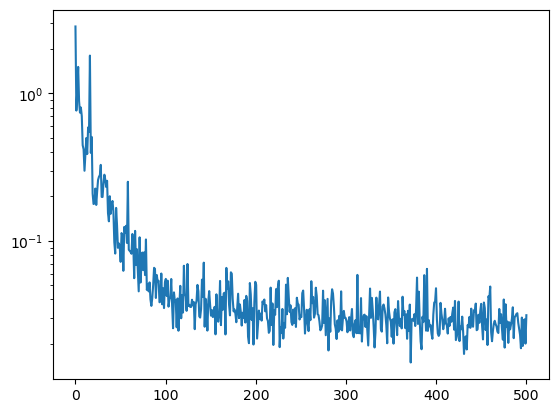

In [33]:
plt.plot(np.linspace(0, EPOCHS, EPOCHS), losses)
plt.yscale('log')